Customer Churn Analysis – Project Overview

The dataset used in this project focuses on customer retention within the telecommunications industry. It contains various features related to customer behavior, subscription details, and usage patterns.

The main objective of this notebook is to perform an exploratory analysis of the dataset in order to better understand the key factors influencing customer churn.

1. This notebook begins by loading a CSV file using the Pandas library, followed by an initial exploration of the dataset, including a preview of the first rows and the column structure.

In [19]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. Understanding the dataset structure
df.info() reveals the data types and non-null counts for each column. TotalCharges appears as object (string) instead of float64, indicating it contains non-numeric values that need to be investigated.

In [20]:
df.info()
(df["TotalCharges"].str.strip() == "").sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

np.int64(11)

3. df.info() revealed that TotalCharges is stored as a string instead of float64. Before converting it, we need to understand why. Which values are causing the issue and what they represent in the dataset.

In [21]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


4. Identifying non-numeric values in TotalCharges

In [22]:
print(df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]["TotalCharges"].unique())

<ArrowStringArray>
[' ']
Length: 1, dtype: str


4. Verifying that non-numeric rows correspond to new customers (tenure = 0)

In [23]:
print(df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]["tenure"].unique())

[0]


5. TotalCharges contains 11 rows with a single whitespace character ' ' instead of a numeric value. These correspond to new customers (tenure = 0) with no billing history yet. They will be converted to NaN using pd.to_numeric() then removed.

Verifying the cleaning — checking row count and updated data types

In [24]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.shape

(7032, 21)

7. Visualizing the Churn distribution

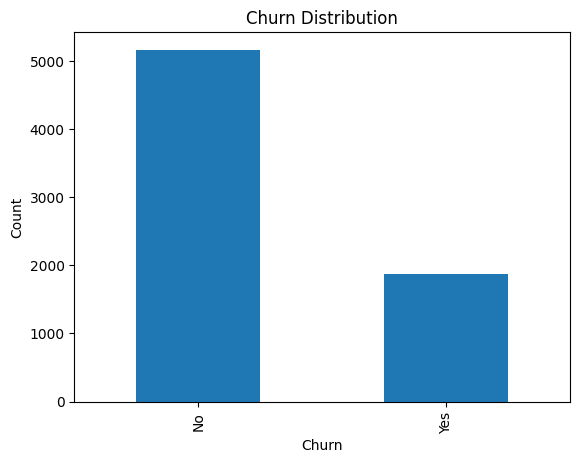

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

&rarr; The dataset is imbalanced, 73,5% No churn vs 26.5% Churn. Class imbalance will be handled using class_weight='balanced' during model training.

12. We explore whether there is a correlation between MontlyCharges, Tenure, Contract, PaymentMethod, InternetService, SeniorCitizen, Dependents, TechSupport and churn rate.

Features selected for analysis:

- tenure — number of months the customer has been with the company
- MonthlyCharges — monthly amount charged to the customer
- Contract — contract type (Month-to-month / One year / Two year)
- PaymentMethod — payment method (Electronic check / Mailed check / Bank transfer / Credit card)
- InternetService — type of internet service (DSL / Fiber optic / No)
- SeniorCitizen — whether the customer is a senior (1 = Yes, 0 = No)
- Dependents — whether the customer has dependents (Yes / No)
- TechSupport — whether the customer has tech support (Yes / No)
- Churn — whether the customer churned (Yes / No) — target variable

AttributeError: Rectangle.set() got an unexpected keyword argument 'multiple'

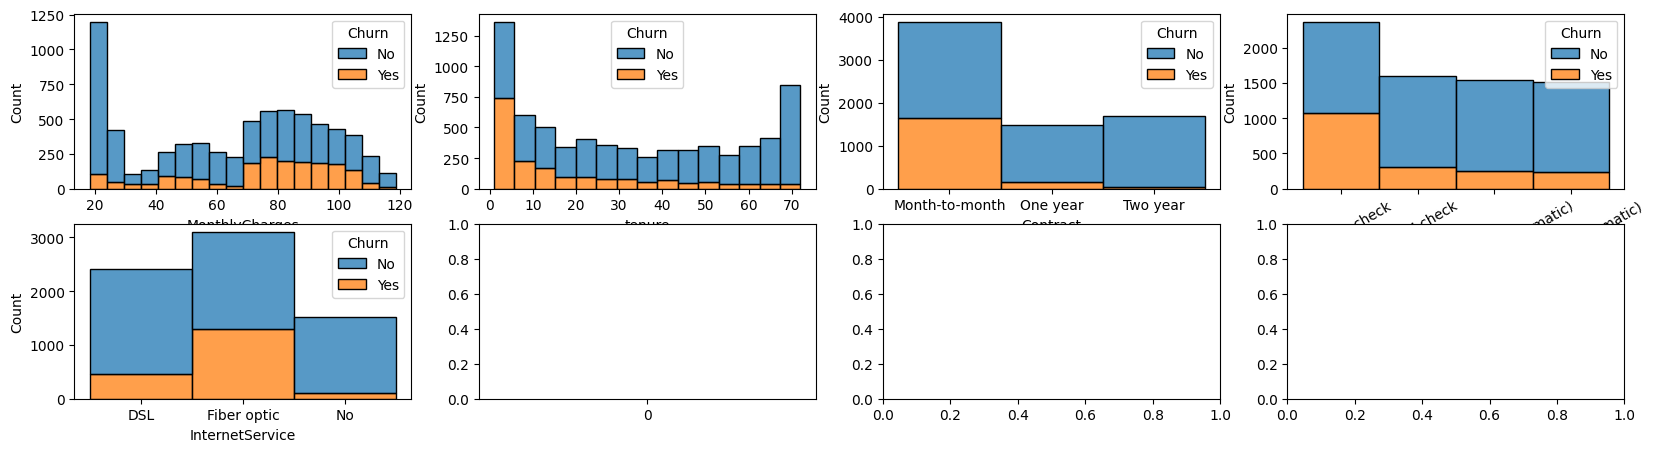

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 5))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", ax=axes[0, 0])
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", ax=axes[0, 1])
sns.histplot(data=df, x="Contract", hue="Churn", multiple="stack", ax=axes[0, 2])
sns.histplot(data=df, x="PaymentMethod", hue="Churn", multiple="stack", ax=axes[0, 3])
axes[0, 3].tick_params(axis="x", labelsize=10, rotation=30)
sns.histplot(data=df, x="InternetService", hue="Churn", multiple="stack", ax=axes[1, 0])
sns.countplot(data=df, x="SeniorCitizen", hue="Churn", ax=axes[1, 1])
sns.histplot(data=df, x="Dependents", hue="Churn", multiple="stack", ax=axes[1, 2])
sns.histplot(data=df, x="TechSupport", hue="Churn", multiple="stack", ax=axes[1, 3]);